# NLP Pipeline v3 — CBA Corpus
### Multimodal Financial Forecasting | Armenian Deposit Dollarization
### Student — Zvarth Aleksanyan

**Design principles:**
- IR and FSR documents scored separately — they carry different signals
- FinBERT replaced by purpose-built CBA tone scorer (central bank language is too hedged for FinBERT)
- LDA replaced by dollarization intensity (transparent, reproducible, not sensitive to random seed)
- Section filtering is document-type specific and surgical
- Date alignment uses actual publication month, not quarter-end month
- Forward-fill capped at 4 months to avoid stale signal

In [33]:
# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import os
import re
import warnings
import numpy as np
import pandas as pd
import pdfplumber
import matplotlib
matplotlib.rcParams.update({
    'figure.facecolor': '#1e1e1e', 'axes.facecolor': '#2d2d2d',
    'axes.edgecolor': '#555', 'text.color': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white',
    'legend.facecolor': '#3d3d3d', 'grid.color': '#444', 'grid.alpha': 0.4
})
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [34]:
# ── 1. PATHS ──────────────────────────────────────────────────────────────────
CORPUS_DIR  = r'Analysis\Data\Unstructured'
OUTPUT_PATH = r'Analysis\Outputs\nlp_features.csv'
PLOT_DIR    = r'Analysis\Outputs'

os.makedirs(PLOT_DIR, exist_ok=True)
print(f'Corpus:  {CORPUS_DIR}')
print(f'Output:  {OUTPUT_PATH}')

Corpus:  Data\Unstructured
Output:  Outputs\nlp_features.csv


## Cell 2 — Document Loading & Date Parsing

Key fix: `QUARTER_MONTH` maps to the actual publication month (month the report becomes available), not the quarter-end month. The Q4 2018 IR was approved November 27 — so it belongs to month 11, not month 12.

In [35]:
# ── 2. DATE PARSING ───────────────────────────────────────────────────────────
#
# IRs are published ~2 months after the quarter they cover:
#   Q1 report → published ~May   → map to '05'
#   Q2 report → published ~Aug   → map to '08'
#   Q3 report → published ~Nov   → map to '11'
#   Q4 report → published ~Feb   → map to '02' of NEXT year
#
# FSRs are published in April of the year following coverage (covering prior year).
#   FSR_2013 → published April 2014 → map to '2014-04'
#
# This ensures NLP features are only available AFTER the document is published.

IR_QUARTER_MAP = {1: ('05', 0), 2: ('08', 0), 3: ('11', 0), 4: ('02', 1)}
# tuple: (month_str, year_offset) — Q4 adds 1 year since published in February of next year

def parse_date_key(filename):
    """
    Returns (date_key as 'YYYY-MM', doc_type as 'IR' or 'FSR').
    Returns (None, None) if filename is not recognised.
    """
    name = os.path.splitext(filename)[0].upper()

    # Inflation Report: IR_YYYY_QX
    m = re.search(r'IR_(\d{4})_Q(\d)', name)
    if m:
        year, q = int(m.group(1)), int(m.group(2))
        month_str, yr_offset = IR_QUARTER_MAP[q]
        pub_year = year + yr_offset
        return f'{pub_year}-{month_str}', 'IR'

    # Financial Stability Report: FSR_YYYY
    m = re.search(r'FSR_(\d{4})', name)
    if m:
        coverage_year = int(m.group(1))
        pub_year = coverage_year + 1   # published April of following year
        return f'{pub_year}-04', 'FSR'

    return None, None


# Quick test
test_cases = [
    ('IR_2018_Q4.pdf', '2019-02', 'IR'),
    ('IR_2018_Q1.pdf', '2018-05', 'IR'),
    ('IR_2018_Q3.pdf', '2018-11', 'IR'),
    ('FSR_2013.pdf',   '2014-04', 'FSR'),
    ('FSR_2021.pdf',   '2022-04', 'FSR'),
]
print('Date parser test:')
all_pass = True
for fname, expected_date, expected_type in test_cases:
    got_date, got_type = parse_date_key(fname)
    status = '✅' if (got_date == expected_date and got_type == expected_type) else '❌'
    if status == '❌':
        all_pass = False
    print(f'  {status} {fname:25s} → {got_date} ({got_type})  [expected {expected_date} ({expected_type})]')
print(f'\n{"All tests passed" if all_pass else "FAILURES — check parser"}')

Date parser test:
  ✅ IR_2018_Q4.pdf            → 2019-02 (IR)  [expected 2019-02 (IR)]
  ✅ IR_2018_Q1.pdf            → 2018-05 (IR)  [expected 2018-05 (IR)]
  ✅ IR_2018_Q3.pdf            → 2018-11 (IR)  [expected 2018-11 (IR)]
  ✅ FSR_2013.pdf              → 2014-04 (FSR)  [expected 2014-04 (FSR)]
  ✅ FSR_2021.pdf              → 2022-04 (FSR)  [expected 2022-04 (FSR)]

All tests passed


## Cell 3 — Text Extraction

In [36]:
# ── 3. TEXT EXTRACTION ────────────────────────────────────────────────────────
def extract_full_text(pdf_path):
    """Extract all text from PDF. Returns empty string on failure."""
    text = ''
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + '\n'
    except Exception as e:
        print(f'  [ERROR] {os.path.basename(pdf_path)}: {e}')
    return text


print('Text extractor ready.')

Text extractor ready.


## Cell 4 — Section Filtering

IR and FSR documents have different relevant sections. We filter to relevant content before scoring.

**IR:** Only the Financial Market Developments section and the Press Release contain dollarization-relevant signal. Everything else (external environment, GDP forecasts, labor market) is noise for this target variable.

**FSR:** Sections on Foreign Exchange Market, Market Risk, Household Income, and any section explicitly mentioning dollarization are relevant.

In [37]:
# ── 4. SECTION FILTERING ──────────────────────────────────────────────────────

# IR: only sections relevant to monetary conditions and FX
IR_TARGET_HEADINGS = [
    'financial market developments',
    'financial market',
    'press release',
    'board decision',
    'money and credit',
    'monetary sector',
    'exchange rate',
    'lending',
    'credit market',
    'box',
    'expectations by the households',
]

# FSR: sections that discuss currency structure, FX risk, dollarization
FSR_TARGET_HEADINGS = [
    'foreign exchange market',
    'market risk',
    'household income',
    'dollarization',
    'foreign currency',
    'currency structure',
    'deposit structure',
    'financial market stability',
    'money and capital market',
    'banking sector',
]

# Keywords: paragraphs must contain at least one to be kept after section match
FX_KEYWORDS = [
    'dollarization', 'dedollarization', 'de-dollarization',
    'foreign currency', 'fx deposit', 'fx loan',
    'dram', 'amd', 'exchange rate', 'usd', 'ruble',
    'deposit', 'refinancing rate', 'reserve requirement',
    'currency', 'monetary policy', 'inflation', 'lending',
    'uncertainty', 'risk', 'depreciation', 'appreciation',
    'remittance', 'capital outflow', 'financial stability',
]


def filter_sections(text, doc_type, min_line_length=40, lines_per_section=60):
    """
    Extract paragraphs from target sections.
    Falls back to keyword filtering across full document if section matching yields < 5 paragraphs.
    """
    target_headings = IR_TARGET_HEADINGS if doc_type == 'IR' else FSR_TARGET_HEADINGS
    lines = text.split('\n')
    relevant = []
    capturing = False
    lines_captured = 0

    for line in lines:
        stripped = line.strip()
        lower   = stripped.lower()

        # Check if this line is a target section heading
        if any(h in lower for h in target_headings) and len(stripped) < 120:
            capturing = True
            lines_captured = 0
            continue

        if capturing:
            if len(stripped) >= min_line_length:
                relevant.append(stripped)
                lines_captured += 1
            if lines_captured >= lines_per_section:
                capturing = False

    # Fallback 1: keyword filtering across full document
    if len(relevant) < 5:
        all_lines = [l.strip() for l in lines if len(l.strip()) >= min_line_length]
        relevant  = [l for l in all_lines
                     if any(kw in l.lower() for kw in FX_KEYWORDS)]

    # Fallback 2: first 80 lines of document
    if len(relevant) < 3:
        relevant = [l.strip() for l in lines
                    if len(l.strip()) >= min_line_length][:80]

    return ' '.join(relevant)


print('Section filter ready.')

Section filter ready.


## Cell 5 — CBA Tone Scorer

**Why not FinBERT:** FinBERT was trained on financial news headlines and analyst reports. Central bank language is institutionally hedged, passive, and avoids strong positive/negative framing by design. A sentence like *"risks to inflation in the medium run are assessed as balanced"* scores near zero on FinBERT because it contains no valence — yet it carries a specific message (balanced risks = no urgency). FinBERT cannot distinguish this from genuinely neutral text.

The CBA tone scorer uses two custom lexicons — concern words and reassurance words — extracted from the actual CBA vocabulary observed in the corpus. The score is directly interpretable: positive = CBA is reassured about FX/financial conditions, negative = CBA is concerned.

In [38]:
# ── 5. CBA TONE SCORER ────────────────────────────────────────────────────────

CONCERN_TERMS = [
    # Risk language
    'risk', 'risks', 'risky', 'vulnerability', 'vulnerab',
    # Negative dynamics
    'deteriorat', 'adverse', 'downside', 'worsen', 'weaken',
    'slowdown', 'contraction', 'decline', 'decrease', 'reduced',
    # Pressure
    'pressure', 'tension', 'stress', 'tighten',
    # Shocks and instability
    'shock', 'disruption', 'spillover', 'volatile', 'volatility',
    'fluctuat', 'instabilit', 'uncertainty', 'uncertain',
    # Crisis
    'crisis', 'distress', 'turmoil', 'threat',
    # FX-specific concern
    'depreciation', 'capital outflow', 'dollarization risk',
    'high level of dollarization', 'fx exposure',
    # Armenia-specific
    'sanction', 'geopolit', 'conflict', 'devaluat', 'ruble deprec',
    # Forecasting concern
    'downside risk', 'prevail', 'exceed target', 'below target',
]

REASSURANCE_TERMS = [
    # Stability
    'stable', 'stability', 'stabiliz', 'robust', 'resilient',
    'sound', 'solid', 'adequate', 'sufficient',
    # Improvement
    'improved', 'improvement', 'strengthened', 'increased confidence',
    'recovery', 'recover', 'rebound',
    # Manageable conditions
    'manageable', 'within regulatory', 'maintained', 'preserved',
    'remained stable', 'no violation', 'complied',
    # De-dollarization
    'de-dollarization', 'dedollarization', 'reduced dollarization',
    'decline in dollarization', 'decrease in foreign currency',
    # Positive monetary policy
    'expansionary', 'accommodative', 'supportive', 'stimulus',
    # Growth confidence
    'growth', 'positive', 'favorable', 'balanced risk',
    'within confidence band', 'close to target',
]


def cba_tone_score(text):
    """
    CBA-specific tone score.
    Returns (reassurance_count - concern_count) / total_words.
    Range: approximately [-0.05, +0.05] for typical CBA documents.
    Positive = CBA is reassured about financial/FX conditions.
    Negative = CBA is concerned.
    """
    if not text or len(text.strip()) < 20:
        return 0.0

    text_lower = text.lower()
    words      = text_lower.split()
    n_words    = len(words)

    if n_words == 0:
        return 0.0

    concern    = sum(1 for w in words if any(c in w for c in CONCERN_TERMS))
    reassure   = sum(1 for w in words if any(r in w for r in REASSURANCE_TERMS))

    return round((reassure - concern) / n_words, 6)


# Sanity check on known text
crisis_text    = 'The banking system faces significant risks from high dollarization and volatile exchange rates. Capital outflow pressures are deteriorating financial stability.'
stable_text    = 'The financial system maintained stability. Dollarization declined. Capital adequacy ratios remained adequate and within regulatory requirements. Recovery continued.'
neutral_text   = 'The Central Bank left the refinancing rate unchanged at 6 percent.'

print('Tone scorer sanity check:')
print(f'  Crisis text:  {cba_tone_score(crisis_text):+.4f}  (should be negative)')
print(f'  Stable text:  {cba_tone_score(stable_text):+.4f}  (should be positive)')
print(f'  Neutral text: {cba_tone_score(neutral_text):+.4f}  (should be near zero)')

Tone scorer sanity check:
  Crisis text:  -0.1500  (should be negative)
  Stable text:  +0.1667  (should be positive)
  Neutral text: +0.0000  (should be near zero)


## Cell 6 — Dollarization Intensity Scorer

**Why not LDA:** LDA on 56 documents with 10 topics means ~5-6 documents per topic. The topic identification by seed word matching is sensitive to random seed and vocabulary construction. Two runs with different seeds can produce completely different topic assignments.

Dollarization intensity directly counts how frequently the CBA mentions dollarization-related terms per thousand words. This is transparent, reproducible, and has a clear interpretation: higher intensity = the CBA is devoting more attention to currency substitution issues.

In [39]:
# ── 6. DOLLARIZATION INTENSITY SCORER ────────────────────────────────────────

DOLLARIZATION_TERMS = [
    # Direct terms (present in early years)
    'dollarization',
    'dedollarization',
    'de-dollarization',
    'foreign currency deposit',
    'fx deposit',
    'foreign currency loan',
    'fx loan',
    'currency structure',
    'dram deposit',
    'amd deposit',
    'foreign exchange deposit',
    # Broader FX engagement terms (present in later years)
    'dram loans',
    'dram liquidity',
    'local currency',
    'foreign currency',
    'exchange rate',
    'usd/amd',
    'reserve requirement',
    'dram-denominated',
    'amd-denominated',
]


def dollarization_intensity(text):
    """
    Count of dollarization-related term occurrences per 1000 words.
    Higher = CBA is discussing currency substitution more.
    """
    if not text or len(text.strip()) < 20:
        return 0.0

    text_lower = text.lower()
    n_words    = len(text_lower.split())

    if n_words == 0:
        return 0.0

    count = 0
    for term in DOLLARIZATION_TERMS:
        if '.*' in term:
            count += len(re.findall(term, text_lower))
        else:
            count += text_lower.count(term)

    return round(count / n_words * 1000, 6)


# Sanity check
high_dol_text = 'Dollarization remained high. Foreign currency deposits constitute 71% of total deposits. The share of fx loans declined. De-dollarization efforts continued. Foreign currency denominated liabilities pose risks.'
low_dol_text  = 'The Board decided to leave the refinancing rate unchanged. Inflation remained within the confidence band. Economic growth continued.'

print('Dollarization intensity sanity check:')
print(f'  High dollarization text:  {dollarization_intensity(high_dol_text):.4f} per 1000 words')
print(f'  Low dollarization text:   {dollarization_intensity(low_dol_text):.4f} per 1000 words')

Dollarization intensity sanity check:
  High dollarization text:  269.2308 per 1000 words
  Low dollarization text:   0.0000 per 1000 words


## Cell 7 — Policy Uncertainty Scorer

In [40]:
# ── 7. POLICY UNCERTAINTY SCORER ─────────────────────────────────────────────

UNCERTAINTY_TERMS = [
    # Core uncertainty
    'uncertain', 'uncertainty', 'unpredictable', 'unclear', 'ambiguous',
    # Risk and hazard
    'risk', 'risks', 'hazard',
    # Volatility
    'volatile', 'volatility', 'fluctuat', 'instabilit',
    # Concern
    'concern', 'challenge', 'threat', 'deteriorat', 'adverse', 'downside', 'worsen',
    # Shocks
    'shock', 'disruption', 'spillover',
    # Pressure
    'pressure', 'tension', 'stress',
    # Crisis
    'crisis', 'crises', 'distress', 'turmoil',
    # Armenia-specific
    'geopolit', 'conflict', 'sanction', 'azerbaijan', 'border',
    'military', 'aggression', 'ruble deprec', 'russian', 'russia',
    'devaluat', 'external shock', 'capital outflow',
    # Forward-looking uncertainty
    'if risks', 'should risks', 'in the event', 'may deviate',
    'uncertainty remains', 'subject to',
]


def policy_uncertainty_score(text):
    """
    Uncertainty word density: count / total_words.
    Higher = more uncertain/concerned language in the document.
    """
    if not text or len(text.strip()) < 20:
        return 0.0

    text_lower = text.lower()
    words      = text_lower.split()
    n_words    = len(words)

    if n_words == 0:
        return 0.0

    count = sum(1 for w in words if any(u in w for u in UNCERTAINTY_TERMS))
    return round(count / n_words, 6)


print('Uncertainty scorer ready.')

Uncertainty scorer ready.


## Cell 8 — Score All Documents

IR and FSR documents are scored separately and kept separate through scoring. They will only be merged in the temporal alignment step.

In [41]:
# ── 8. SCORE ALL DOCUMENTS ────────────────────────────────────────────────────

pdf_files = sorted([f for f in os.listdir(CORPUS_DIR) if f.lower().endswith('.pdf')])
print(f'Found {len(pdf_files)} PDF files in corpus.\n')

records  = []
skipped  = []

print('── Stage 1: Extract & filter text ──')
for fname in tqdm(pdf_files):
    date_key, doc_type = parse_date_key(fname)
    if date_key is None:
        skipped.append(fname)
        continue

    full_path     = os.path.join(CORPUS_DIR, fname)
    raw_text      = extract_full_text(full_path)
    filtered_text = filter_sections(raw_text, doc_type)

    records.append({
        'filename':      fname,
        'date_key':      date_key,
        'doc_type':      doc_type,
        'text':          filtered_text,
        'raw_word_count': len(raw_text.split()),
        'filt_word_count': len(filtered_text.split()),
    })

if skipped:
    print(f'\n⚠️  Skipped (unrecognised filename):')
    for f in skipped:
        print(f'   {f}')
    print('   → Rename to IR_YYYY_QX.pdf or FSR_YYYY.pdf')

n_ir  = sum(1 for r in records if r['doc_type'] == 'IR')
n_fsr = sum(1 for r in records if r['doc_type'] == 'FSR')
print(f'\nExtracted: {len(records)} documents ({n_ir} IR, {n_fsr} FSR)')

print('\n── Stage 2: Score documents ──')
results = []
for record in tqdm(records):
    text     = record['text']
    tone     = cba_tone_score(text)
    dol_int  = dollarization_intensity(text)
    unc      = policy_uncertainty_score(text)

    results.append({
        'date_key':              record['date_key'],
        'filename':              record['filename'],
        'doc_type':              record['doc_type'],
        'cba_tone':              tone,
        'dollarization_intensity': dol_int,
        'policy_uncertainty':    unc,
        'raw_words':             record['raw_word_count'],
        'filtered_words':        record['filt_word_count'],
    })

df_scores = pd.DataFrame(results)
df_scores['Date'] = pd.to_datetime(df_scores['date_key'])
df_scores = df_scores.sort_values('Date').reset_index(drop=True)

print('\n── Score summary by document type ──')
print(df_scores.groupby('doc_type')[['cba_tone', 'dollarization_intensity', 'policy_uncertainty']].describe().round(4))

Found 69 PDF files in corpus.

── Stage 1: Extract & filter text ──


100%|██████████| 69/69 [17:45<00:00, 15.44s/it]  



Extracted: 69 documents (56 IR, 13 FSR)

── Stage 2: Score documents ──


100%|██████████| 69/69 [00:09<00:00,  7.39it/s]


── Score summary by document type ──
         cba_tone                                                          \
            count    mean     std     min     25%     50%     75%     max   
doc_type                                                                    
FSR          13.0 -0.0068  0.0036 -0.0114 -0.0098 -0.0071 -0.0057 -0.0003   
IR           56.0  0.0032  0.0082 -0.0153 -0.0033  0.0046  0.0089  0.0195   

         dollarization_intensity          ...                  \
                           count    mean  ...     75%     max   
doc_type                                  ...                   
FSR                         13.0  1.9236  ...  2.3874  3.3278   
IR                          56.0  2.1714  ...  3.4750  7.4627   

         policy_uncertainty                                                  \
                      count    mean     std     min     25%     50%     75%   
doc_type                                                                      
FSR          

In [42]:
# ── Detailed score table ───────────────────────────────────────────────────────
display_cols = ['date_key', 'doc_type', 'filename', 'cba_tone',
                'dollarization_intensity', 'policy_uncertainty',
                'filtered_words']
print('Per-document scores (sorted by date):')
display(df_scores[display_cols].to_string(index=False))

Per-document scores (sorted by date):


'date_key doc_type       filename  cba_tone  dollarization_intensity  policy_uncertainty  filtered_words\n 2012-05       IR IR_2012_Q1.pdf  0.008824                 4.603875            0.010934            5213\n 2012-08       IR IR_2012_Q2.pdf  0.012474                 3.413866            0.007222            7616\n 2012-11       IR IR_2012_Q3.pdf  0.006189                 3.031451            0.008968            7917\n 2013-02       IR IR_2012_Q4.pdf  0.005618                 2.387640            0.008708            7120\n 2013-04      FSR   FSR_2012.pdf -0.003471                 3.327847            0.015816           27946\n 2013-05       IR IR_2013_Q1.pdf  0.008644                 3.117472            0.006377            7057\n 2013-08       IR IR_2013_Q2.pdf  0.008983                 5.293551            0.003369            6234\n 2013-11       IR IR_2013_Q3.pdf  0.002990                 6.860158            0.006157            5685\n 2014-02       IR IR_2013_Q4.pdf  0.008415            

## Cell 9 — Temporal Alignment

Forward-fill is capped at 4 months (`limit=4`) to prevent stale signal from propagating across too many periods.

In [43]:
# ── 9. TEMPORAL ALIGNMENT ────────────────────────────────────────────────────

NLP_COLS = ['cba_tone', 'dollarization_intensity', 'policy_uncertainty']

# Separate IR and FSR
df_ir  = df_scores[df_scores['doc_type'] == 'IR'].copy()
df_fsr = df_scores[df_scores['doc_type'] == 'FSR'].copy()

# Average per date (in case multiple documents share a date)
df_ir_agg  = df_ir.groupby('Date')[NLP_COLS].mean().reset_index()
df_fsr_agg = df_fsr.groupby('Date')[NLP_COLS].mean().reset_index()

# Rename columns to distinguish source
df_ir_agg  = df_ir_agg.rename(columns={c: f'ir_{c}'  for c in NLP_COLS})
df_fsr_agg = df_fsr_agg.rename(columns={c: f'fsr_{c}' for c in NLP_COLS})

# Build monthly date range: 2012-01 to 2025-12
date_range  = pd.date_range(start='2012-01-01', end='2025-12-01', freq='MS')
df_monthly  = pd.DataFrame({'Date': date_range})

# Merge IR features
df_monthly = df_monthly.merge(df_ir_agg,  on='Date', how='left')
# Merge FSR features
df_monthly = df_monthly.merge(df_fsr_agg, on='Date', how='left')

# Forward-fill both feature sets independently, capped at 4 months
ir_cols  = [c for c in df_monthly.columns if c.startswith('ir_')]
fsr_cols = [c for c in df_monthly.columns if c.startswith('fsr_')]

df_monthly[ir_cols]  = df_monthly[ir_cols].ffill(limit=4)
df_monthly[fsr_cols] = df_monthly[fsr_cols].ffill(limit=4)

# Report coverage
all_feature_cols = ir_cols + fsr_cols
print('Coverage after forward-fill:')
for col in all_feature_cols:
    n_obs   = df_monthly[col].notna().sum()
    pct     = n_obs / len(df_monthly) * 100
    print(f'  {col:<35} {n_obs:3d} / {len(df_monthly)} months ({pct:.0f}%)')

# Drop months where neither IR nor FSR data is available
df_monthly_clean = df_monthly.dropna(subset=all_feature_cols, how='all').reset_index(drop=True)
print(f'\nMonthly observations with at least one NLP feature: {len(df_monthly_clean)}')
print(f'Date range: {df_monthly_clean.Date.min().date()} → {df_monthly_clean.Date.max().date()}')

Coverage after forward-fill:
  ir_cba_tone                         164 / 168 months (98%)
  ir_dollarization_intensity          164 / 168 months (98%)
  ir_policy_uncertainty               164 / 168 months (98%)
  fsr_cba_tone                         65 / 168 months (39%)
  fsr_dollarization_intensity          65 / 168 months (39%)
  fsr_policy_uncertainty               65 / 168 months (39%)

Monthly observations with at least one NLP feature: 164
Date range: 2012-05-01 → 2025-12-01


## Cell 10 — Validation & Plots

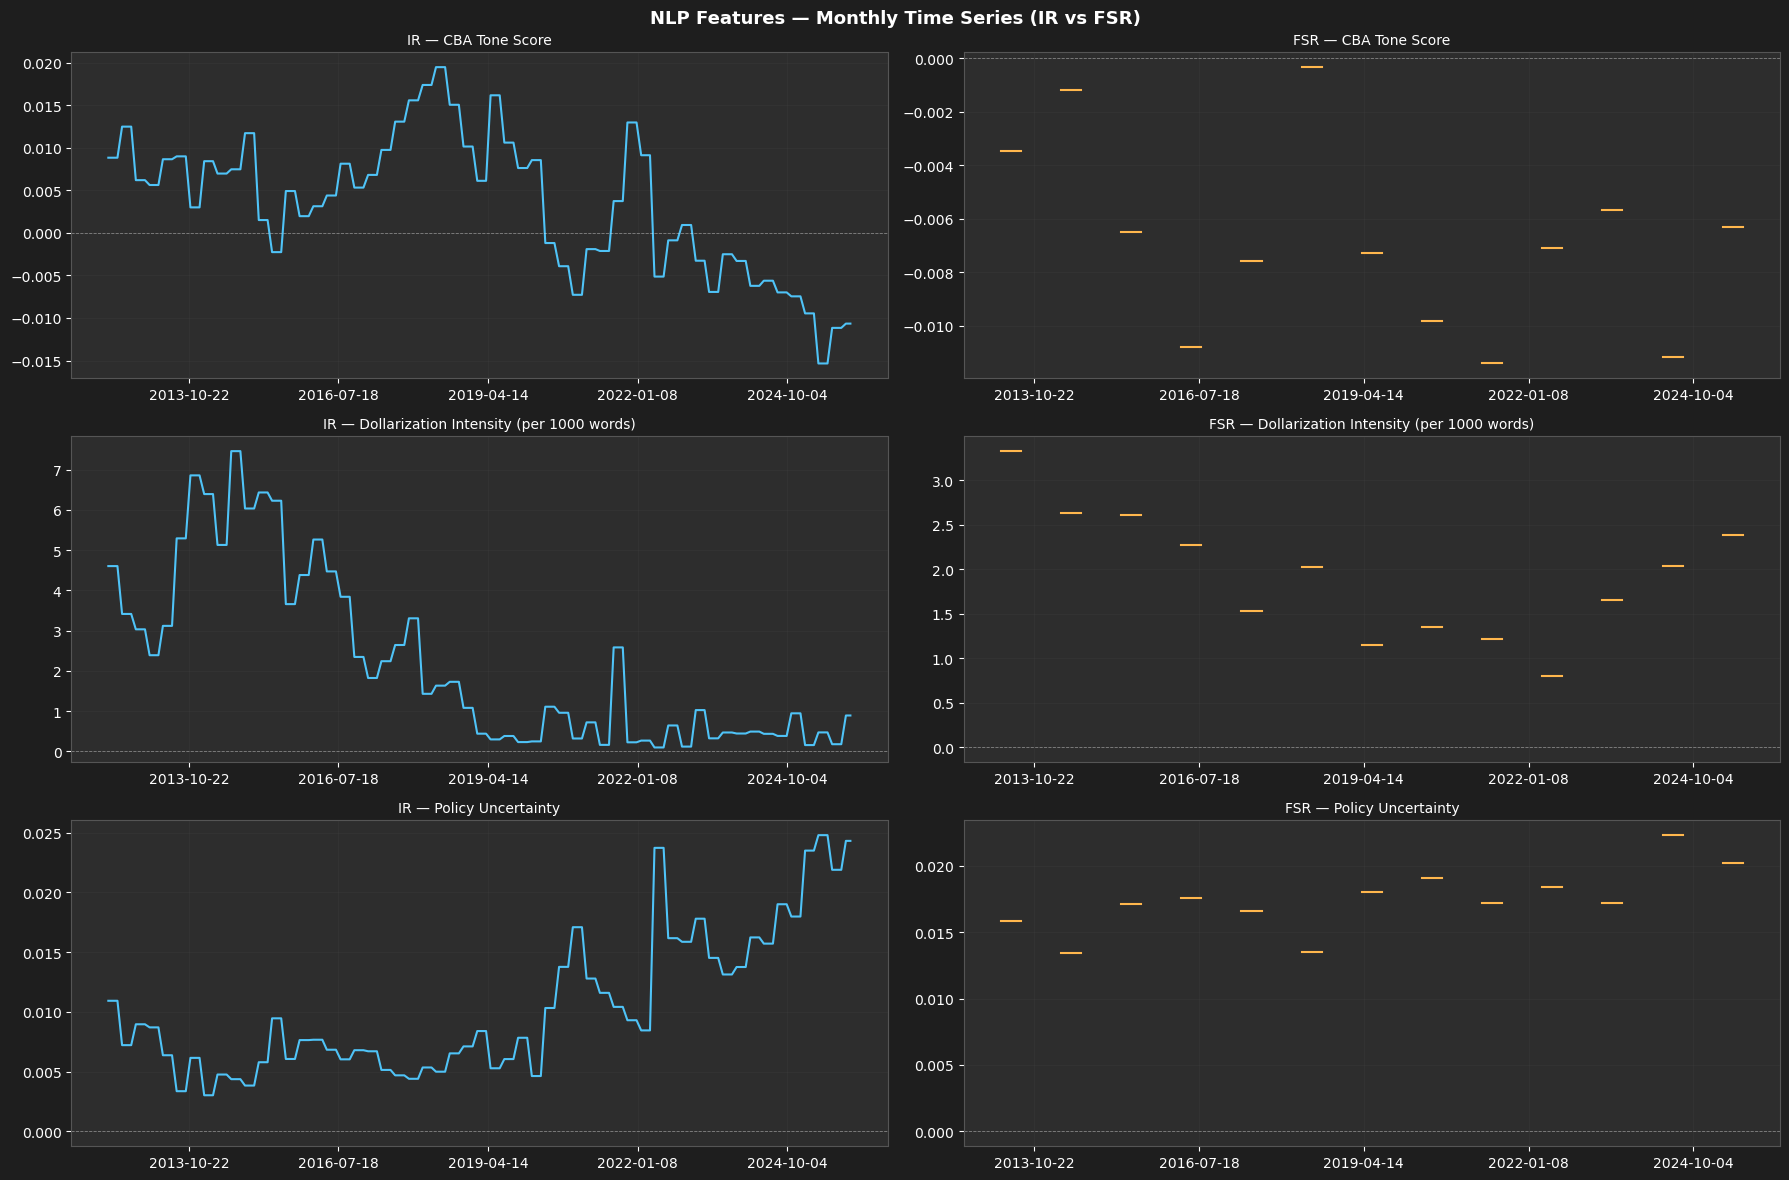

Time series plot saved.


In [44]:
# ── 10a. Feature time series plots ───────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('NLP Features — Monthly Time Series (IR vs FSR)', fontweight='bold', fontsize=13)

plot_pairs = [
    ('ir_cba_tone',                'fsr_cba_tone',                '#4fc3f7', '#ffb74d', 'CBA Tone Score'),
    ('ir_dollarization_intensity', 'fsr_dollarization_intensity', '#4fc3f7', '#ffb74d', 'Dollarization Intensity (per 1000 words)'),
    ('ir_policy_uncertainty',      'fsr_policy_uncertainty',      '#4fc3f7', '#ffb74d', 'Policy Uncertainty'),
]

for row, (ir_col, fsr_col, ir_color, fsr_color, title) in enumerate(plot_pairs):
    for col_idx, (col_name, color, label) in enumerate([
        (ir_col,  ir_color,  'IR'),
        (fsr_col, fsr_color, 'FSR'),
    ]):
        ax = axes[row, col_idx]
        if col_name in df_monthly_clean.columns:
            ax.plot(df_monthly_clean['Date'], df_monthly_clean[col_name],
                    color=color, linewidth=1.5, label=label)
            ax.axhline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
        ax.set_title(f'{label} — {title}', fontsize=10)
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'nlp_features_v3_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Time series plot saved.')

In [45]:
# ── 10b. Correlation with dollarization data ───────────────────────────────────
# Load the structured database to check NLP feature correlations with target

DB_PATH = r'Data\Structured\Database_CBA_Rates and indicators.xlsx'

try:
    df_struct = pd.read_excel(DB_PATH)
    df_struct.columns = (df_struct.columns.str.strip().str.lower()
                         .str.replace(' ', '_')
                         .str.replace(r'[^a-z0-9_]', '', regex=True))
    date_col   = [c for c in df_struct.columns if 'date' in c][0]
    df_struct['Date'] = pd.to_datetime(df_struct[date_col])
    df_struct['Date'] = df_struct['Date'].dt.to_period('M').dt.to_timestamp()

    df_monthly_clean['Date_m'] = df_monthly_clean['Date'].dt.to_period('M').dt.to_timestamp()
    df_merged = df_monthly_clean.merge(
        df_struct[['Date', 'd2_deposit_dollarization']],
        left_on='Date_m', right_on='Date', how='inner'
    )

    print(f'Merged observations for correlation check: {len(df_merged)}')
    print('\nCorrelation with d2_deposit_dollarization:')
    corr_cols = [c for c in all_feature_cols if c in df_merged.columns]
    corr_vals = df_merged[corr_cols + ['d2_deposit_dollarization']].corr()['d2_deposit_dollarization'].drop('d2_deposit_dollarization')
    print(corr_vals.sort_values().round(4).to_string())

except FileNotFoundError:
    print('Structured database not found at expected path — skipping correlation check.')
    print('Run this cell after confirming DB_PATH is correct.')

Merged observations for correlation check: 164

Correlation with d2_deposit_dollarization:
ir_policy_uncertainty         -0.7823
fsr_policy_uncertainty        -0.6421
fsr_cba_tone                   0.3402
fsr_dollarization_intensity    0.5332
ir_cba_tone                    0.6158
ir_dollarization_intensity     0.8068


In [46]:
# ── 10c. Feature summary statistics ───────────────────────────────────────────
print('=== NLP Feature Summary Statistics ===')
print(df_monthly_clean[all_feature_cols].describe().round(6))

print('\n=== Missing value audit ===')
for col in all_feature_cols:
    n_miss = df_monthly_clean[col].isna().sum()
    print(f'  {col:<35} {n_miss} missing')

=== NLP Feature Summary Statistics ===
       ir_cba_tone  ir_dollarization_intensity  ir_policy_uncertainty  \
count   164.000000                  164.000000             164.000000   
mean      0.003482                    2.210844               0.010342   
std       0.008058                    2.165811               0.005878   
min      -0.015343                    0.093423               0.003029   
25%      -0.002705                    0.380228               0.006035   
50%       0.004910                    1.106807               0.008401   
75%       0.008983                    3.658419               0.013959   
max       0.019461                    7.462687               0.024792   

       fsr_cba_tone  fsr_dollarization_intensity  fsr_policy_uncertainty  
count     65.000000                    65.000000               65.000000  
mean      -0.006810                     1.923578                0.017402  
std        0.003443                     0.696941                0.002341  
min

## Cell 11 — Save Output

Output columns ready for merge with structured pipeline:
- `ir_cba_tone` — CBA tone from Inflation Reports (monetary policy confidence)
- `ir_dollarization_intensity` — dollarization discussion intensity in IRs
- `ir_policy_uncertainty` — uncertainty language density in IRs
- `fsr_cba_tone` — CBA tone from Financial Stability Reports
- `fsr_dollarization_intensity` — dollarization discussion intensity in FSRs
- `fsr_policy_uncertainty` — uncertainty language density in FSRs

**LASSO merge plan (pending professor approval):**
```python
LASSO_VARS_MULTIMODAL = LASSO_VARS + [
    'ir_cba_tone', 'ir_dollarization_intensity', 'ir_policy_uncertainty',
    'fsr_cba_tone', 'fsr_dollarization_intensity', 'fsr_policy_uncertainty',
]
```

In [47]:
# ── 11. SAVE ─────────────────────────────────────────────────────────────────
output_cols = ['Date'] + all_feature_cols
df_final    = df_monthly_clean[output_cols].copy()

df_final.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Saved: {OUTPUT_PATH}')
print(f'   Shape: {df_final.shape}')
print(f'   Date range: {df_final.Date.min().date()} → {df_final.Date.max().date()}')
print(f'   Features: {all_feature_cols}')
print()
print('Preview (first 6 rows):')
print(df_final.head(6).to_string(index=False))

✅ Saved: Outputs\nlp_features.csv
   Shape: (164, 7)
   Date range: 2012-05-01 → 2025-12-01
   Features: ['ir_cba_tone', 'ir_dollarization_intensity', 'ir_policy_uncertainty', 'fsr_cba_tone', 'fsr_dollarization_intensity', 'fsr_policy_uncertainty']

Preview (first 6 rows):
      Date  ir_cba_tone  ir_dollarization_intensity  ir_policy_uncertainty  fsr_cba_tone  fsr_dollarization_intensity  fsr_policy_uncertainty
2012-05-01     0.008824                    4.603875               0.010934           NaN                          NaN                     NaN
2012-06-01     0.008824                    4.603875               0.010934           NaN                          NaN                     NaN
2012-07-01     0.008824                    4.603875               0.010934           NaN                          NaN                     NaN
2012-08-01     0.012474                    3.413866               0.007222           NaN                          NaN                     NaN
2012-09-01     0

In [48]:
# ── 11b. Per-document score log ───────────────────────────────────────────────
# Save detailed per-document scores for methodology appendix
log_path = OUTPUT_PATH.replace('nlp_features_v3.csv', 'nlp_document_scores_v3.csv')
df_scores[['date_key', 'doc_type', 'filename',
           'cba_tone', 'dollarization_intensity', 'policy_uncertainty',
           'raw_words', 'filtered_words']].to_csv(log_path, index=False)
print(f'Document-level score log saved: {log_path}')

Document-level score log saved: Outputs\nlp_features.csv
